# Week 6 Homework 

## Exercise #1 
Use the 2015, 2005, and 1995 tree data,
- Plot the bar chart of total tree counts by borough for 2015, 2005, 1995
- Plot the pie chart of the top ten species for 2015 in each borough
- plot histograms of tree_dbh for 2015, 2005, and 1995


In [3]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
tree2015 = pd.read_csv('../05/data/2015_Street_Tree_Census.csv')
tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')                       
tree1995 = pd.read_csv('../05/data/1995_Street_Tree_Census.csv')

C:\Users\Wenge\AppData\Local\Temp\ipykernel_7108\1646282599.py:2: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')


In [9]:
tree2015.columns

Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward',
       'guards', 'sidewalk', 'user_type', 'problems', 'root_stone',
       'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other',
       'brch_light', 'brch_shoe', 'brch_other', 'address', 'postcode',
       'zip_city', 'community board', 'borocode', 'borough', 'cncldist',
       'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state',
       'latitude', 'longitude', 'x_sp', 'y_sp', 'council district',
       'census tract', 'bin', 'bbl'],
      dtype='object')

In [18]:
tree1995.columns

Index(['RecordId', 'Address', 'House_Number', 'Street', 'Postcode_Original',
       'Community Board_Original', 'Site', 'Species', 'Diameter', 'Condition',
       'Wires', 'Sidewalk_Condition', 'Support_Structure', 'Borough', 'X', 'Y',
       'Longitude', 'Latitude', 'CB_New', 'Zip_New', 'CensusTract_2010',
       'CensusBlock_2010', 'NTA_2010', 'SegmentID', 'Spc_Common', 'Spc_Latin',
       'Location', 'Council District', 'BIN', 'BBL'],
      dtype='object')

In [5]:
tree2005.loc[tree2005.borocode == 5, 'boroname'] = 'Staten Island'
tree2005[tree2005.borocode == 5].boroname

429490    Staten Island
429508    Staten Island
429574    Staten Island
429676    Staten Island
429872    Staten Island
              ...      
592367    Staten Island
592368    Staten Island
592369    Staten Island
592370    Staten Island
592371    Staten Island
Name: boroname, Length: 99701, dtype: object

Text(0, 0.5, 'Tree Count')

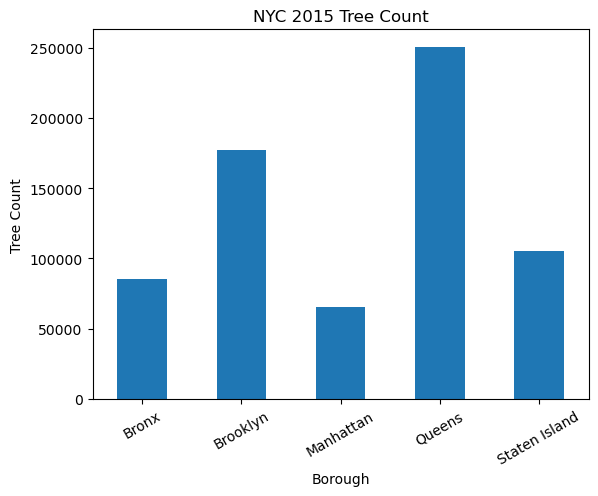

In [16]:
# Number of tree counts by species 
# treecounts = tree2015.groupby('spc_common').size()
tree2015.groupby('borough').size().plot.bar(title = 'NYC 2015 Tree Count')
plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('Borough')
plt.ylabel('Tree Count')


In [20]:
# create a df to include all tree counts
treecount = pd.DataFrame({
    '2015': tree2015.groupby('borough').size(),
    '2005': tree2005.groupby('boroname').size(),
    '1995': tree1995.groupby('Borough').size()}                
)
treecount

,2015,2005,1995
Bronx,85203,59925,48487
Brooklyn,177293,142852,117101
Manhattan,65423,49886,47215
Queens,250551,240008,227552
Staten Island,105318,99701,76634


Text(0, 0.5, 'Tree Count')

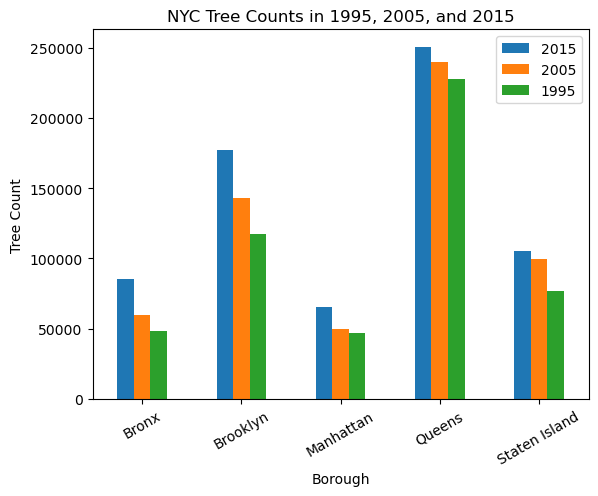

In [21]:
treecount.plot(kind = 'bar')
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')

In [ ]:
treecount.plot(kind = 'bar', stacked = True)
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')

<Axes: title={'center': 'Top 10 Dominant Species in 2015'}>

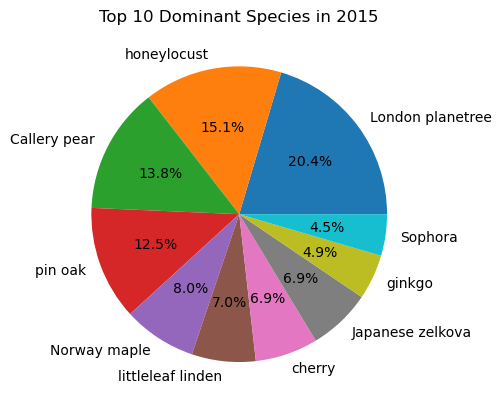

In [22]:
# find the top 10 dominant species 
treecount2015 = tree2015.groupby('spc_common').size()
treecount2015_sorted = treecount2015.sort_values(ascending=False)
treecount2015_sorted[0:10]
# pie chart for top ten dominant species 
treecount2015_sorted[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015')

<Axes: title={'center': 'Top 10 Dominant Species in 2015 in Staten Island'}>

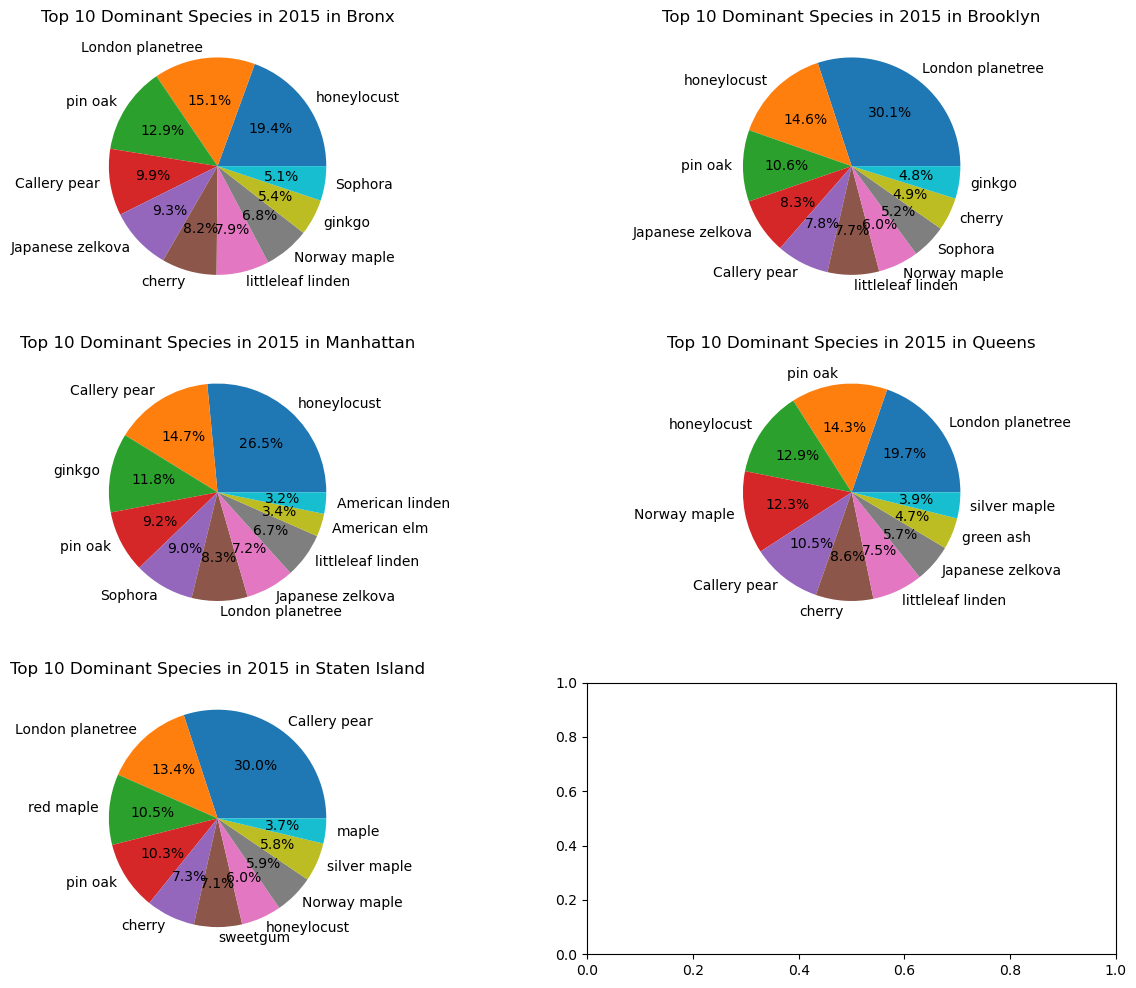

In [35]:

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

tree2015[tree2015.borough =='Bronx'].groupby('spc_common').size().sort_values(ascending=False)[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015 in Bronx',ax=axes[0, 0])
tree2015[tree2015.borough =='Brooklyn'].groupby('spc_common').size().sort_values(ascending=False)[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015 in Brooklyn',ax=axes[0, 1])
tree2015[tree2015.borough =='Manhattan'].groupby('spc_common').size().sort_values(ascending=False)[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015 in Manhattan',ax=axes[1, 0])
tree2015[tree2015.borough =='Queens'].groupby('spc_common').size().sort_values(ascending=False)[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015 in Queens',ax=axes[1, 1])
tree2015[tree2015.borough =='Staten Island'].groupby('spc_common').size().sort_values(ascending=False)[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015 in Staten Island',ax=axes[2, 0])
 

<Axes: ylabel='Frequency'>

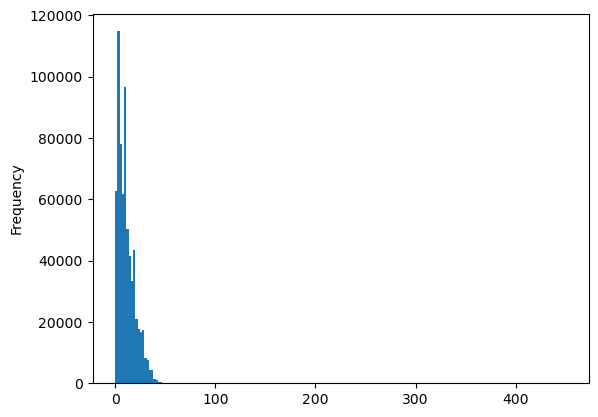

In [24]:
tree2015['tree_dbh'].plot(kind='hist', bins=200)
#tree2015.plot(kind='hist, column='tree_dbh', bins=200)

## Exercise #2 
Use EPA AQI data to compare the air quality (AQI) for the five boroughs

In [37]:
pm25_daily_2024= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_88101_2024.zip', parse_dates=['Date Local']) 

C:\Users\Wenge\AppData\Local\Temp\ipykernel_7108\3836455058.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  pm25_daily_2024= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_88101_2024.zip', parse_dates=['Date Local'])


In [39]:
pm25_daily_2024.shape

(729819, 29)

In [40]:
pm25_NY_2024 = pm25_daily_2024.loc[(pm25_daily_2024['County Name']== 'New York'), ['Site Num', 'Local Site Name', 'Date Local', 'AQI']]
pm25_NY_2024

,Site Num,Local Site Name,Date Local,AQI
441075,79,IS 45,2024-01-01,47.0
441076,79,IS 45,2024-01-04,42.0
441077,79,IS 45,2024-01-07,15.0
441078,79,IS 45,2024-01-10,14.0
441079,79,IS 45,2024-01-13,19.0
...,...,...,...,...
441373,128,PS 19,2024-12-17,32.0
441374,128,PS 19,2024-12-20,30.0
441375,128,PS 19,2024-12-23,38.0
441376,128,PS 19,2024-12-26,56.0


(array([19723., 19783., 19844., 19905., 19967., 20028., 20089.]),
 [Text(19723.0, 0, '2024-01'),
  Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01')])

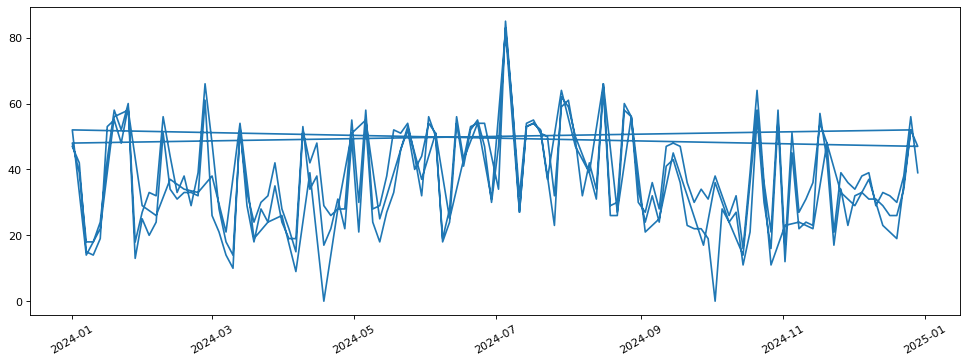

In [41]:
# plot the time series of AQI 
plt.figure(figsize=(15,5), dpi=80)
plt.subplot(1, 1, 1)
plt.plot(pm25_NY_2024['Date Local'], pm25_NY_2024['AQI'])
plt.xticks(rotation = 30, horizontalalignment = 'center')